In [1]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import uniform
import scipy.stats
from scipy import optimize
from astroML import stats as astroMLstats
from sklearn.neighbors import KernelDensity

In [2]:
counts = 10000
vec_M = np.random.normal(1, 0.02, size=counts)
vec_a = np.random.uniform(0, 1, size=counts)

In [3]:
def f(a):
    return np.sqrt((1+np.sqrt(1-a**2))/2)

In [4]:
def M_irr(M, a):
    return M*f(a)

In [5]:
vec_M_irr = M_irr(vec_M, vec_a)
vec_f = f(vec_a)

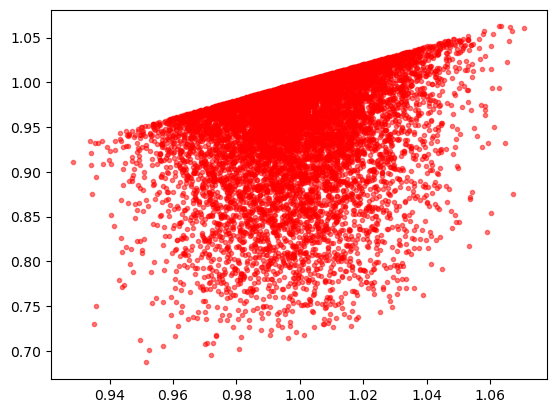

In [6]:
plt.scatter(vec_M, vec_M_irr, color="r", marker=".", alpha=0.5)

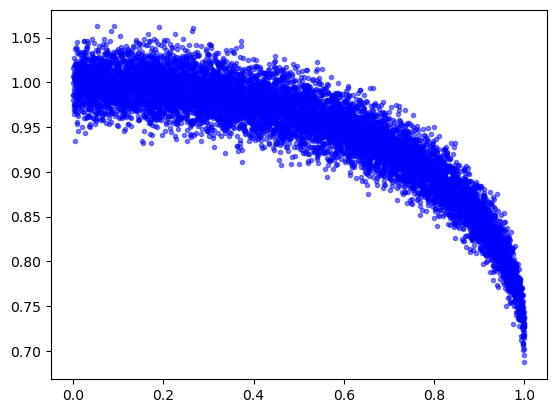

In [7]:
plt.scatter(vec_a, vec_M_irr, color="b", marker=".", alpha=0.5)

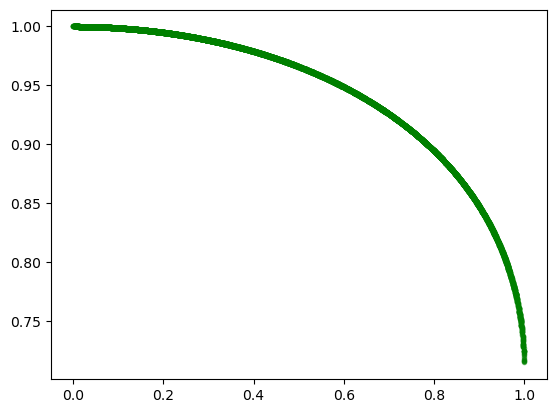

In [8]:
plt.scatter(vec_a, vec_f, color="g", marker=".", alpha=0.5)

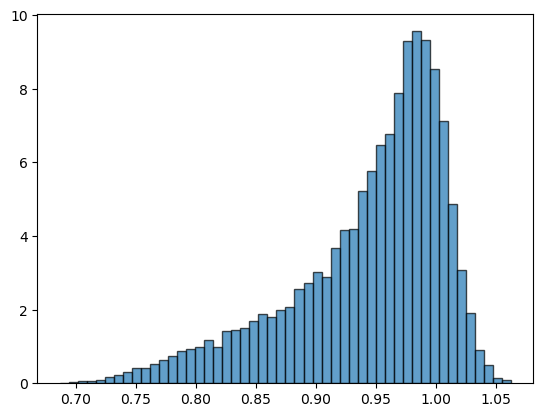

In [9]:
_,_,_=plt.hist(vec_M_irr, bins=50, density=True, edgecolor="black", alpha=0.7)

In [10]:
# making variable-width bin sizes that have the same number of objects in each bin.
bins100 = np.append(np.sort(vec_M_irr)[::100], np.max(vec_M_irr))
bins500 = np.append(np.sort(vec_M_irr)[::500], np.max(vec_M_irr))

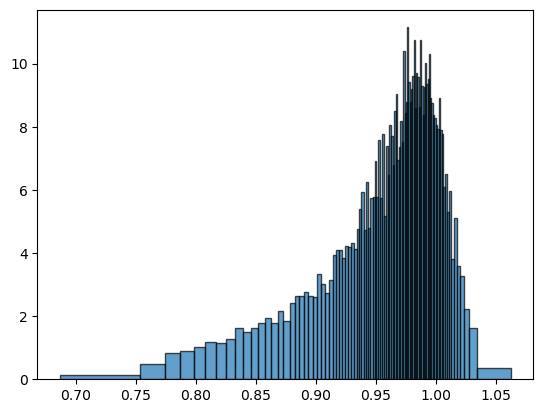

In [11]:
_,_,_=plt.hist(vec_M_irr, bins=bins100, density=True, edgecolor="black", alpha=0.7)

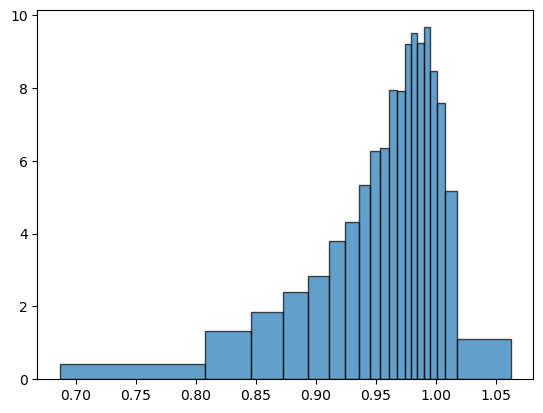

In [12]:
_,_,_=plt.hist(vec_M_irr, bins=bins500, density=True, edgecolor="black", alpha=0.7)

In [13]:
# define a KDE 
def kde_sklearn(data, bandwidth, kernel, grid):
    kde_skl = KernelDensity(bandwidth = bandwidth, kernel = kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(grid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

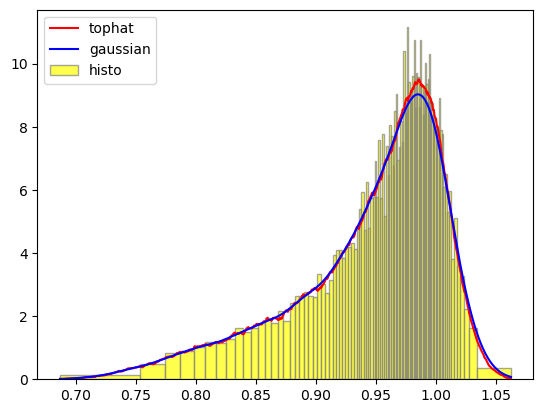

In [14]:
grid = np.linspace(vec_M_irr.min(), vec_M_irr.max(), 1000)
PDF = kde_sklearn(vec_M_irr, 0.01, "gaussian", grid) 
PDF_tophat = kde_sklearn(vec_M_irr, 0.01, "tophat", grid) 

plt.plot(grid, PDF_tophat, "-r", label="tophat")
plt.plot(grid, PDF, "-b", label="gaussian")
plt.hist(vec_M_irr, bins=bins100, density=True, edgecolor="gray", color="yellow", alpha=0.7, label="histo")
plt.legend()

In [15]:
# try some KS tests
?stats.ks_2samp

Signature: stats.ks_2samp(data1, data2, alternative='two-sided', method='auto')
Docstring:
Performs the two-sample Kolmogorov-Smirnov test for goodness of fit.

This test compares the underlying continuous distributions F(x) and G(x)
of two independent samples.  See Notes for a description of the available
null and alternative hypotheses.

Parameters
----------
data1, data2 : array_like, 1-Dimensional
    Two arrays of sample observations assumed to be drawn from a continuous
    distribution, sample sizes can be different.
alternative : {'two-sided', 'less', 'greater'}, optional
    Defines the null and alternative hypotheses. Default is 'two-sided'.
    Please see explanations in the Notes below.
method : {'auto', 'exact', 'asymp'}, optional
    Defines the method used for calculating the p-value.
    The following options are available (default is 'auto'):

      * 'auto' : use 'exact' for small size arrays, 'asymp' for large
      * 'exact' : use exact distribution of test statisti

In [16]:
vec_sigma = np.logspace(-4, 4, 1000)
list_M_irr = []
list_M = []
for sigma_i in vec_sigma:
    temp_M = np.random.normal(1, sigma_i, size=counts)
    list_M_irr.append(M_irr(temp_M, vec_a))
    list_M.append(temp_M)

In [17]:
# Suppose we wish to test the null hypothesis that two samples were drawn from the same distribution.
# We choose a confidence level of 95%; that is, we will reject the null hypothesis in favor of the alternative if the p-value is less than 0.05.

vec1_ks = [stats.ks_2samp(M_irr_i, vec_f)[0] for M_irr_i in list_M_irr]
vec2_ks = [stats.ks_2samp(list_M_irr[i], list_M[i])[0] for i in range(len(list_M_irr))]

vec1_p = [stats.ks_2samp(M_irr_i, vec_f)[1] for M_irr_i in list_M_irr]
vec2_p = [stats.ks_2samp(list_M_irr[i], list_M[i])[1] for i in range(len(list_M_irr))]

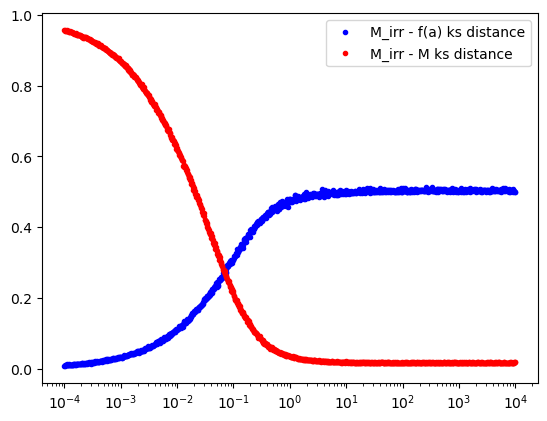

In [18]:
plt.plot(vec_sigma, vec1_ks, '.b', label="M_irr - f(a) ks distance")
plt.plot(vec_sigma, vec2_ks, '.r', label="M_irr - M ks distance")
plt.xscale("log")
plt.legend()

Suppose we wish to test the null hypothesis that two samples were drawn from the same distribution.

We choose a confidence level of 95%; that is, we will reject the null hypothesis in favor of the alternative if the p-value is less than 0.05.

You should find that (i) $M_{irr}$ is distributed like $f$ if ${\sigma}\ll \mu$ and (ii) $M_{irr}$ is distributed like $M$ if  $\sigma\gg \mu$.

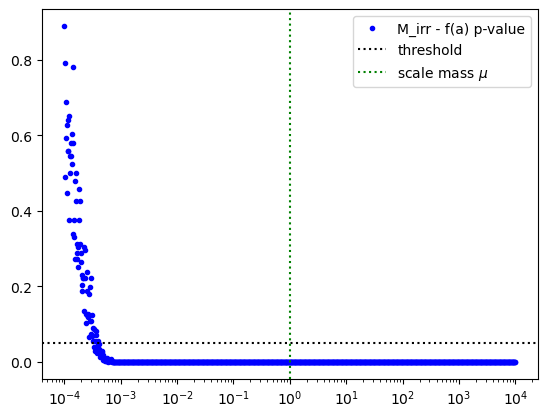

In [19]:
plt.plot(vec_sigma, vec1_p, '.b', label="M_irr - f(a) p-value")
plt.axhline(0.05, c='black', ls='dotted', label='threshold')
plt.axvline(1, c='green', ls='dotted', label=r'scale mass $\mu$')
plt.xscale("log")
# plt.yscale("log")
plt.legend()

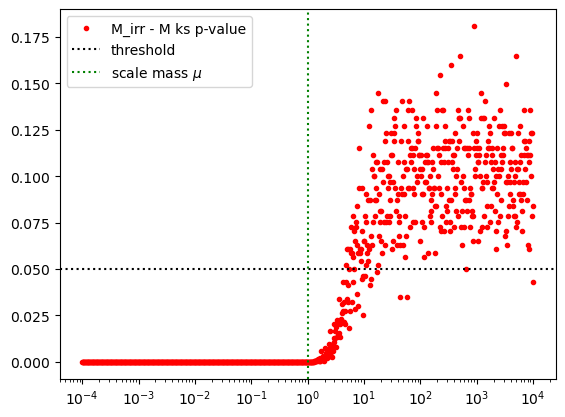

In [20]:
plt.plot(vec_sigma, vec2_p, '.r', label="M_irr - M ks p-value")
plt.axhline(0.05, c='black', ls='dotted', label='threshold')
plt.axvline(1, c='green', ls='dotted', label=r'scale mass $\mu$')
plt.xscale("log")
# plt.yscale("log")
plt.legend()